TUGAS PDE FISIKA KOMPUTASI LANJUT\
ARDIANSAH NUR ROHMAN\
230322607922

TUGAS 1

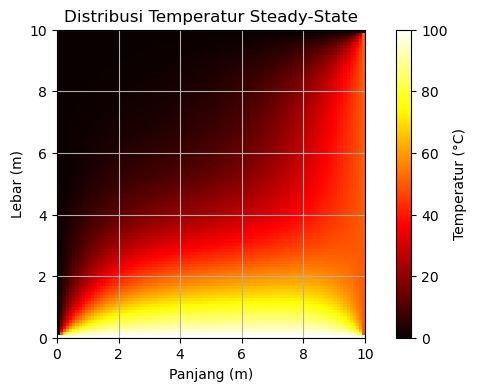

In [3]:

import numpy as np
import matplotlib.pyplot as plt

#parameter
L = 10.0  # panjang domain dalam meter
N = 100  # jumlah grid dalam setiap arah
W = 5.0   # lebar domain dalam meter
dx = dy = L / (N-1)  # ukuran grid

#inisialisasi temperatur
T = np.zeros((N, N))


#syarat batas
T[:, 0] = 0.0  # kiri
T[:, -1] = 50.0  # kanan
T[0, :] = 100.0   # atas
T[-1, :] = 0.0   # bawah

#iterasi Gauss-Seidel
max_iter = 1000
tolerance = 1e-5
for iteration in range(max_iter):
    T_old = T.copy()

    for i in range(1, N-1):
        for j in range(1, N-1):
            T[i, j] = 0.25 * (T[i+1, j] + T[i-1, j] + T[i, j+1] + T[i, j-1])
    
    #cek konvergensi
    np.max(np.abs(T - T_old))
    error = np.max(np.abs(T - T_old ))
    if error < tolerance:
        print(f"Konvergen setelah {iteration + 1} iterasi.")
        break

#visualisasi hasil
plt.figure(figsize=(8, 4))
plt.imshow(T, cmap='hot', origin='lower', extent=[0, L, 0, L])
plt.colorbar(label='Temperatur (°C)')
plt.xlabel('Panjang (m)')
plt.ylabel('Lebar (m)')
plt.title('Distribusi Temperatur Steady-State')
plt.grid()
plt.show()


TUGAS 2

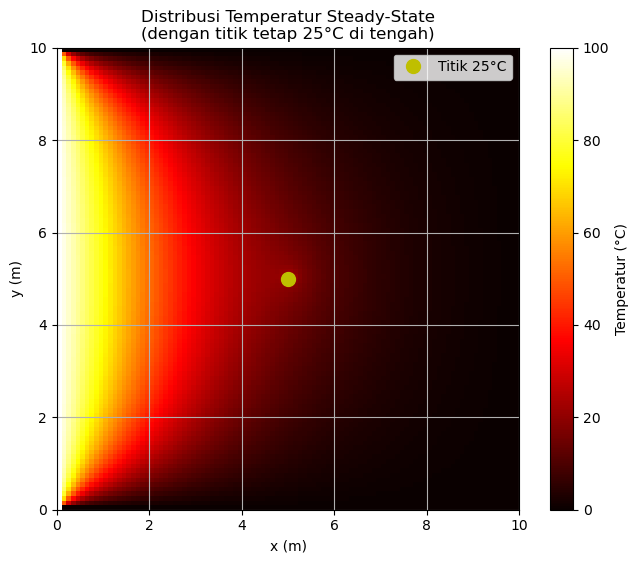

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parameter
L = 10.0          # panjang domain dalam meter
N = 100           # jumlah grid dalam setiap arah
dx = dy = L / (N - 1)

# Inisialisasi temperatur
T = np.zeros((N, N))

# Syarat batas
T[:, 0] = 0.0     # kiri (x=0)
T[:, -1] = 0.0    # kanan (x=L)
T[0, :] = 0.0     # atas (y=L) — baris pertama jika origin='lower'
T[-1, :] = 0.0    # bawah (y=0)

T[:, 0] = 100.0   # PERBAIKAN: sisi kiri = 100°C (sesuai gambar)

# Titik tengah: (L/2, L/2) → indeks [N//2, N//2]
mid_i = N // 2
mid_j = N // 2

# Iterasi Gauss-Seidel
max_iter = 1000
tolerance = 1e-5
for iteration in range(max_iter):
    T_old = T.copy()

    for i in range(1, N - 1):
        for j in range(1, N - 1):
            # Jangan update titik tengah secara numerik
            if i == mid_i and j == mid_j:
                continue  # lewati, akan di-set manual nanti
            T[i, j] = 0.25 * (T[i + 1, j] + T[i - 1, j] + T[i, j + 1] + T[i, j - 1])
    
    # Paksa titik tengah tetap 25°C
    T[mid_i, mid_j] = 25.0

    # Hitung error
    error = np.max(np.abs(T - T_old))
    if error < tolerance:
        print(f"Konvergen setelah {iteration + 1} iterasi.")
        break

# Visualisasi hasil
plt.figure(figsize=(8, 6))
plt.imshow(T, cmap='hot', origin='lower', extent=[0, L, 0, L])
plt.colorbar(label='Temperatur (°C)')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Distribusi Temperatur Steady-State\n(dengan titik tetap 25°C di tengah)')
plt.grid()

# Tandai titik tengah
plt.plot(L/2, L/2, 'yo', markersize=10, label='Titik 25°C')
plt.legend()
plt.show()